# 🌍 Global Market Analysis — Indian Investor Perspective
**Comparing 10 global equity markets: Returns, P/E, CAPE, Volatility, and Forecasting**

---
**Methodology:**
- Index data sourced from `all_pe_cape.xlsx`
- Currency data (INR/USD + USD/local) fetched from **Yahoo Finance**
- Total return = Index return + Currency return (INR terms)
- All analysis is data-driven; no manual calculations

## 1. 📦 Imports & Setup

In [134]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
from scipy import stats
from scipy.stats import spearmanr
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap

pio.templates.default = 'plotly_white'

# Color palette for 10 countries
COUNTRY_COLORS = {
    'USA':          '#2196F3',
    'UK':           '#9C27B0',
    'TAIWAN':       '#00BCD4',
    'INDONASIA':    '#FF9800',
    'INDIA':        '#F44336',
    'CHINA':        '#E91E63',
    'SOUTH AFRICA': '#4CAF50',
    'BRAZIL':       '#009688',
    'SOUTH KOREA':  '#3F51B5',
    'JAPAN':        '#FF5722',
}

COUNTRIES = list(COUNTRY_COLORS.keys())
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. 📂 Load Index Data from Excel

In [135]:
EXCEL_PATH = 'all_pe_cape.xlsx'
START = '2020-01-01'
END   = '2026-06-30'

INDEX_TICKERS = {
    'USA':          '^GSPC',
    'UK':           '^FTSE',
    'TAIWAN':       '^TWII',
    'INDONASIA':    '^JKSE',
    'INDIA':        '^NSEI',
    'CHINA':        '000001.SS',
    'SOUTH AFRICA': '^J200.JO',
    'BRAZIL':       '^BVSP',
    'SOUTH KOREA':  '^KS11',
    'JAPAN':        '^N225',
}

xl = pd.read_excel(EXCEL_PATH, sheet_name=None)

raw_data = {}
for country, ticker in INDEX_TICKERS.items():
    print(f'Downloading index for {country} ({ticker}) ...')
    raw = yf.download(ticker, start=START, end=END, interval='1mo', auto_adjust=True, progress=False)
    raw.index = raw.index.to_period('M').to_timestamp()
    index_df = raw[['Close']].copy()
    index_df.columns = ['Index_Level']
    index_df.index.name = 'Month'
    index_df = index_df.reset_index()

    # Load P/E and CAPE from Excel
    pe_df = xl[country][['Month', 'P/E', 'CAPE']].copy()
    pe_df['Month'] = pd.to_datetime(pe_df['Month']).dt.to_period('M').dt.to_timestamp()

    # Merge on Month
    merged = pd.merge(index_df, pe_df, on='Month', how='left')
    merged = merged.sort_values('Month').reset_index(drop=True)
    raw_data[country] = merged

print('\n✅ All index data downloaded and merged with P/E & CAPE')
raw_data['INDIA'].head()


✅ All index data downloaded and merged with P/E & CAPE


,Month,Index_Level,P/E,CAPE
0,2020-01-01,11962.099609,28.3,25.80
1,2020-02-01,11201.750000,27.8,25.30
2,2020-03-01,8597.750000,25.1,22.90
3,2020-04-01,9859.900391,19.3,17.65
4,2020-05-01,9580.299805,21.1,19.20


## 3. 💱 Fetch Currency Data from Yahoo Finance

For each foreign country we need:
- **INR/USD** rate (how many INR per 1 USD)
- **USD/LocalCurrency** rate (to convert index to USD, then to INR)

**Logic:** `INR Value = Index_Level / (LocalCurrency per USD) * (INR per USD)`

In [136]:
# Yahoo Finance ticker for each country's currency vs USD
# These are units of LOCAL CURRENCY per 1 USD
FX_TICKERS = {
    'USA':          None,          # Index already in USD
    'UK':           'GBPUSD=X',    # GBP per USD → invert to get USD per GBP
    'TAIWAN':       'TWD=X',       # TWD per USD
    'INDONASIA':    'IDR=X',       # IDR per USD
    'INDIA':        None,          # Home country — no conversion needed
    'CHINA':        'CNY=X',       # CNY per USD
    'SOUTH AFRICA': 'ZAR=X',       # ZAR per USD
    'BRAZIL':       'BRL=X',       # BRL per USD
    'SOUTH KOREA':  'KRW=X',       # KRW per USD
    'JAPAN':        'JPY=X',       # JPY per USD
}

# INR per USD
INR_TICKER = 'INR=X'

START = '2020-01-01'
END   = '2026-06-30'

print('Fetching INR/USD ...')
inr_raw = yf.download(INR_TICKER, start=START, end=END, interval='1mo', auto_adjust=True, progress=False)
inr_raw.index = inr_raw.index.to_period('M').to_timestamp()
inr_series = inr_raw['Close'].squeeze()
print(f'  INR/USD fetched: {len(inr_series)} months')

fx_data = {}
for country, ticker in FX_TICKERS.items():
    if ticker is None:
        fx_data[country] = None
        continue
    print(f'Fetching {ticker} for {country} ...')
    raw = yf.download(ticker, start=START, end=END, interval='1mo', auto_adjust=True, progress=False)
    raw.index = raw.index.to_period('M').to_timestamp()
    # For GBP/USD yfinance gives USD per GBP; we need GBP per USD → invert
    if ticker == 'GBPUSD=X':
        fx_data[country] = 1.0 / raw['Close'].squeeze()
    else:
        fx_data[country] = raw['Close'].squeeze()

print('\n✅ All currency data fetched')

Fetching INR/USD ...
  INR/USD fetched: 78 months
Fetching GBPUSD=X for UK ...
Fetching TWD=X for TAIWAN ...
Fetching IDR=X for INDONASIA ...
Fetching CNY=X for CHINA ...
Fetching ZAR=X for SOUTH AFRICA ...
Fetching BRL=X for BRAZIL ...
Fetching KRW=X for SOUTH KOREA ...
Fetching JPY=X for JAPAN ...

✅ All currency data fetched


## 4. 🔄 Build INR-Converted Returns

**Formula for each foreign market:**
```
Index_in_USD  = Index_Level / (Local per USD)
Index_in_INR  = Index_in_USD * (INR per USD)
INR_Return_%  = pct_change(Index_in_INR)
```
For India (home): monthly return is just `pct_change(Nifty_Level)` — no currency adjustment.

For USA: index is already in USD → `Index_in_INR = Index_Level * (INR per USD)`

In [140]:
for country in COUNTRIES:
    df = raw_data[country].copy().set_index('Month')

    if country == 'INDIA':
        df['INR_Index']        = df['Index_Level']
        df['Index_Return_Pct'] = df['Index_Level'].pct_change() * 100
        df['FX_USDINR_Pct']    = 0.0   # you are already in INR
        df['FX_LocalUSD_Pct']  = 0.0
        df['FX_Total_Pct']     = 0.0

    elif country == 'USA':
        inr_aligned            = inr_series.reindex(df.index, method='nearest')
        df['INR_Index']        = df['Index_Level'] * inr_aligned
        df['Index_Return_Pct'] = df['Index_Level'].pct_change() * 100

        # Only one FX component — INR vs USD
        df['FX_USDINR_Pct']   = inr_aligned.pct_change().values * 100   # INR/USD rate rising = INR depreciating = GOOD for investor
        df['FX_LocalUSD_Pct'] = 0.0   # index is already in USD, no local-vs-USD component
        df['FX_Total_Pct']    = df['FX_USDINR_Pct']

    else:
        fx_aligned             = fx_data[country].reindex(df.index, method='nearest')   # local per USD
        inr_aligned            = inr_series.reindex(df.index, method='nearest')          # INR per USD

        df['USD_Index']        = df['Index_Level'] / fx_aligned
        df['INR_Index']        = df['USD_Index'] * inr_aligned
        df['Index_Return_Pct'] = df['Index_Level'].pct_change() * 100

        # Component 1: INR depreciation vs USD (same for ALL foreign markets)
        inr_ret                = inr_aligned.pct_change()
        df['FX_USDINR_Pct']   = inr_ret.values * 100

        # Component 2: Local currency strengthening vs USD
        # local_per_USD going DOWN means local currency got stronger vs USD = good for you
        local_usd_ret          = (1 / fx_aligned).pct_change()
        df['FX_LocalUSD_Pct'] = local_usd_ret.values * 100

        # Combined FX return (multiplicative, not additive)
        df['FX_Total_Pct']    = ((1 + inr_ret) * (1 + local_usd_ret) - 1).values * 100

    df['INR_Return_Pct'] = df['INR_Index'].pct_change() * 100
    combined[country] = df.reset_index()

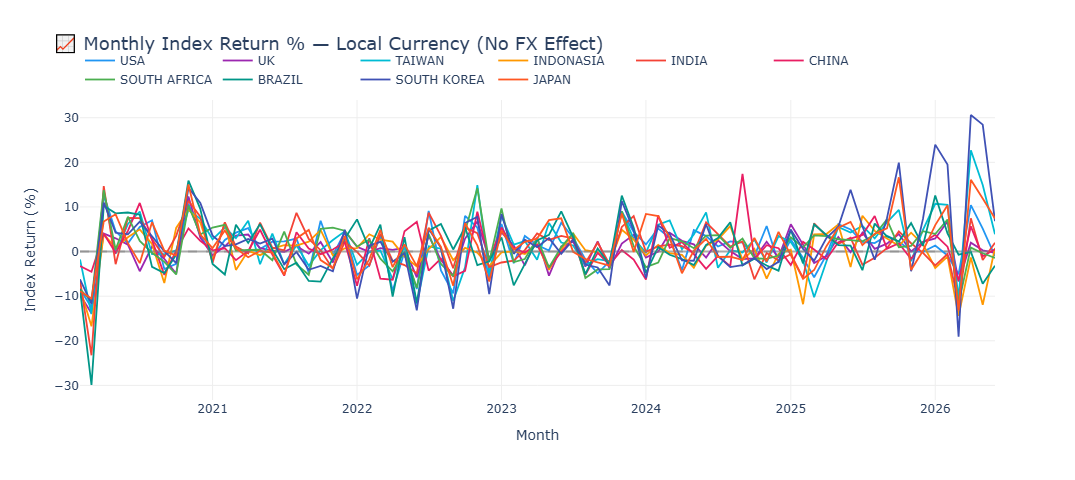

In [141]:
# --- Graph 1: Index Return (local currency) ---
fig = go.Figure()

for country in COUNTRIES:
    # 1. Check if the country exists in your dictionary to prevent a different KeyError
    if country in combined:
        df = combined[country]
        
        # 2. Check if the column actually exists in this country's DataFrame
        if 'Index_Return_Pct' in df.columns:
            df = df.dropna(subset=['Index_Return_Pct'])
            
            fig.add_trace(go.Scatter(
                x=df['Month'], y=df['Index_Return_Pct'],
                name=country, line=dict(color=COUNTRY_COLORS[country], width=1.8), mode='lines'
            ))
        else:
            print(f"Warning: 'Index_Return_Pct' column missing for {country}. Available columns: {list(df.columns)}")
    else:
        print(f"Warning: {country} not found in the 'combined' dictionary.")

fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5)
fig.update_layout(
    title=dict(text='📈 Monthly Index Return % — Local Currency (No FX Effect)', font=dict(size=18)),
    xaxis_title='Month', yaxis_title='Index Return (%)',
    height=480, hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee', zeroline=True, zerolinecolor='#aaa'),
    xaxis=dict(gridcolor='#eee')
)
fig.show()

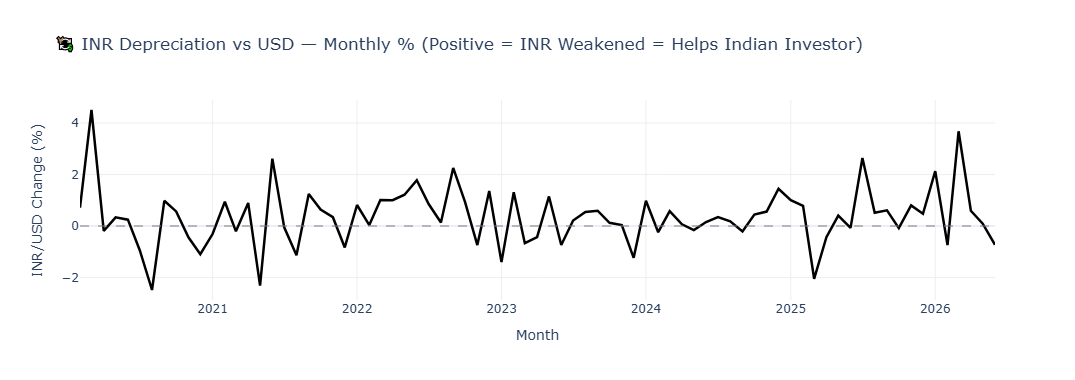

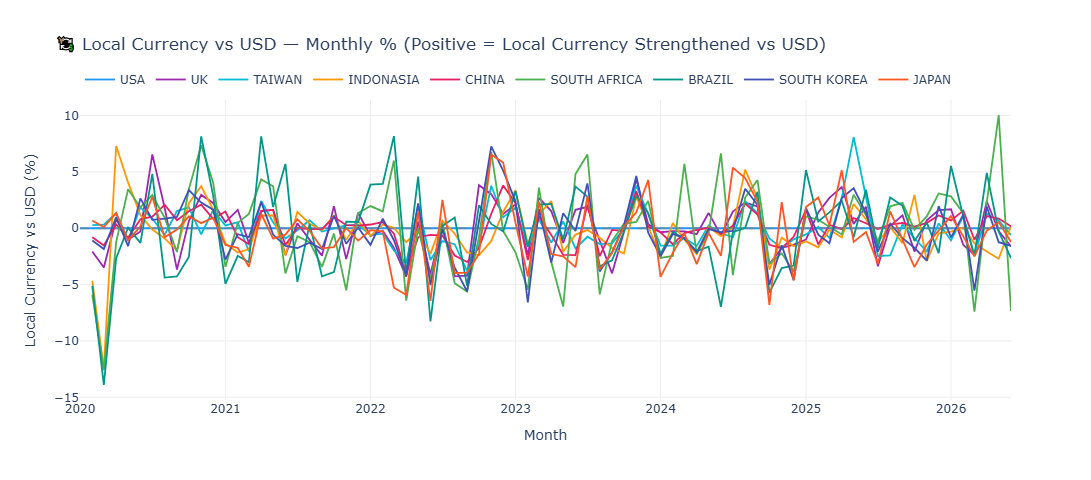


📋 Full Return Decomposition — Indian Investor View:
   Positive INR/USD = INR weakened vs USD = boosts your foreign returns when converted back


,Country,Ann. Index Return (%),Ann. INR/USD Depreciation (%),Ann. Local vs USD (%),Ann. Total FX Effect (%),Ann. Total INR Return (%)
0,TAIWAN,24.22%,4.37%,-0.51%,3.79%,28.39%
1,SOUTH KOREA,26.94%,4.37%,-3.54%,0.70%,28.20%
2,USA,14.70%,4.37%,0.00%,4.37%,18.83%
3,JAPAN,19.50%,4.37%,-5.65%,-1.38%,17.60%
4,SOUTH AFRICA,13.04%,4.37%,-0.75%,3.38%,17.37%
5,BRAZIL,8.82%,4.37%,-2.17%,2.04%,12.63%
6,INDIA,12.59%,0.00%,0.00%,0.00%,12.59%
7,UK,6.38%,4.37%,0.48%,4.69%,11.21%
8,CHINA,6.05%,4.37%,0.51%,4.81%,10.92%
9,INDONASIA,1.95%,4.37%,-3.75%,0.44%,2.91%


In [144]:
# Graph 2a: INR/USD depreciation contribution (same curve for all non-India markets)
fig_usdinr = go.Figure()
# Only need one line since USDINR is the same for all foreign markets
df_usa = combined['USA'].dropna(subset=['FX_USDINR_Pct'])
fig_usdinr.add_trace(go.Scatter(
    x=df_usa['Month'], y=df_usa['FX_USDINR_Pct'],
    name='INR/USD Move', line=dict(color='black', width=2.5), mode='lines'
))
fig_usdinr.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5)
fig_usdinr.update_layout(
    title=dict(text='💱 INR Depreciation vs USD — Monthly % (Positive = INR Weakened = Helps Indian Investor)', font=dict(size=17)),
    xaxis_title='Month', yaxis_title='INR/USD Change (%)',
    height=380, plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'), xaxis=dict(gridcolor='#eee')
)
fig_usdinr.show()

# Graph 2b: Local currency vs USD (different per country)
fig_local = go.Figure()
for country in COUNTRIES:
    if country == 'INDIA':
        continue
    df = combined[country].dropna(subset=['FX_LocalUSD_Pct'])
    fig_local.add_trace(go.Scatter(
        x=df['Month'], y=df['FX_LocalUSD_Pct'],
        name=country, line=dict(color=COUNTRY_COLORS[country], width=1.8), mode='lines'
    ))
fig_local.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5)
fig_local.update_layout(
    title=dict(text='💱 Local Currency vs USD — Monthly % (Positive = Local Currency Strengthened vs USD)', font=dict(size=17)),
    xaxis_title='Month', yaxis_title='Local Currency vs USD (%)',
    height=480, hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'), xaxis=dict(gridcolor='#eee')
)
fig_local.show()

# Updated decomposition table — now shows all 3 components
table_rows = []
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Return_Pct'])
    avg_idx      = df['Index_Return_Pct'].mean() * 12
    avg_usdinr   = df['FX_USDINR_Pct'].mean() * 12
    avg_localusd = df['FX_LocalUSD_Pct'].mean() * 12
    avg_fx_total = df['FX_Total_Pct'].mean() * 12
    avg_tot      = df['INR_Return_Pct'].mean() * 12
    table_rows.append({
        'Country':                        country,
        'Ann. Index Return (%)':          round(avg_idx, 2),
        'Ann. INR/USD Depreciation (%)':  round(avg_usdinr, 2),   # positive = INR weakened = helped you
        'Ann. Local vs USD (%)':          round(avg_localusd, 2),
        'Ann. Total FX Effect (%)':       round(avg_fx_total, 2),
        'Ann. Total INR Return (%)':      round(avg_tot, 2),
    })

table_df = pd.DataFrame(table_rows).sort_values('Ann. Total INR Return (%)', ascending=False).reset_index(drop=True)
print('\n📋 Full Return Decomposition — Indian Investor View:')
print('   Positive INR/USD = INR weakened vs USD = boosts your foreign returns when converted back')
display(table_df.style.format({
    'Ann. Index Return (%)':         '{:.2f}%',
    'Ann. INR/USD Depreciation (%)': '{:.2f}%',
    'Ann. Local vs USD (%)':         '{:.2f}%',
    'Ann. Total FX Effect (%)':      '{:.2f}%',
    'Ann. Total INR Return (%)':     '{:.2f}%',
}).background_gradient(subset=['Ann. Total INR Return (%)'], cmap='RdYlGn'))

## 5. 📅 Year-on-Year Return Analysis (INR Terms)

For each calendar year, we compute the **total return** using the INR-adjusted index level (first vs last month of the year).

In [145]:
def calc_yearly_return(df, country):
    """Calculate annual return for a country using INR_Index levels."""
    df = df.copy()
    df['Year'] = df['Month'].dt.year
    df = df.dropna(subset=['INR_Index'])
    rows = []
    for year, grp in df.groupby('Year'):
        grp = grp.sort_values('Month')
        start_val = grp['INR_Index'].iloc[0]
        end_val   = grp['INR_Index'].iloc[-1]
        ret = (end_val / start_val - 1) * 100
        rows.append({'Year': year, 'Country': country, 'Annual_Return_Pct': round(ret, 2)})
    return pd.DataFrame(rows)

yearly_list = []
for country in COUNTRIES:
    yearly_list.append(calc_yearly_return(combined[country], country))

yearly_df = pd.concat(yearly_list, ignore_index=True)

# Pivot for easy reading
yearly_pivot = yearly_df.pivot(index='Country', columns='Year', values='Annual_Return_Pct')
yearly_pivot.columns.name = None
print('\n📊 Year-on-Year Returns (INR-Adjusted %):')
yearly_pivot.style.format('{:.1f}%').background_gradient(cmap='RdYlGn', axis=1)


📊 Year-on-Year Returns (INR-Adjusted %):


,2020,2021,2022,2023,2024,2025,2026
Country,,,,,,,
BRAZIL,-12.5%,-9.6%,9.6%,26.0%,-22.1%,42.0%,-4.2%
CHINA,26.7%,7.6%,-6.7%,-12.0%,20.6%,29.8%,4.9%
INDIA,16.9%,27.3%,4.4%,23.0%,8.8%,11.2%,-5.2%
INDONASIA,1.4%,12.5%,5.7%,4.6%,-0.5%,22.7%,-28.1%
JAPAN,27.5%,-3.3%,-6.3%,14.3%,6.5%,29.8%,31.9%
SOUTH AFRICA,11.6%,14.0%,-0.3%,-8.0%,14.5%,61.0%,-5.5%
SOUTH KOREA,51.3%,-4.1%,-11.3%,5.2%,-10.3%,73.9%,68.9%
TAIWAN,40.8%,24.4%,-19.9%,16.2%,26.4%,34.5%,49.0%
UK,-5.7%,15.9%,-0.6%,3.5%,9.3%,28.6%,0.9%


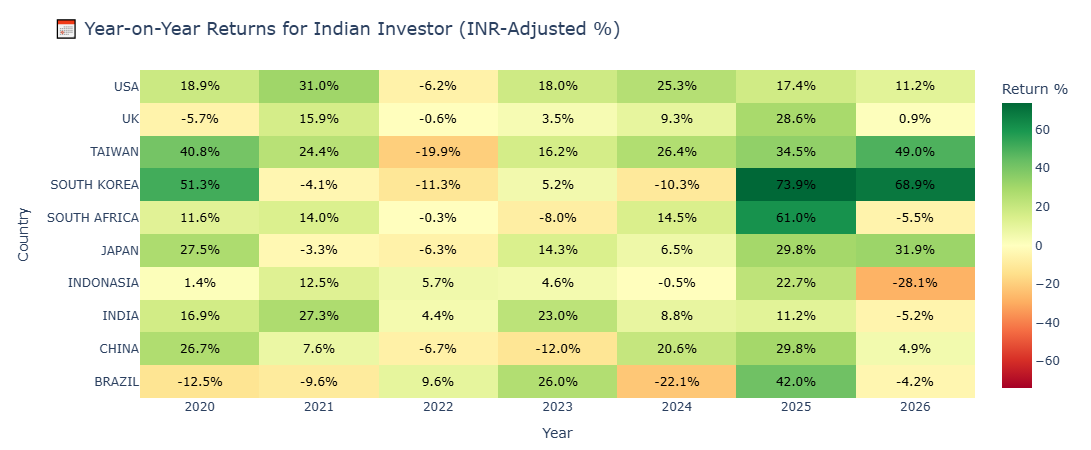

In [146]:
# ---- Heatmap: Year-on-Year Returns ----
fig = go.Figure(data=go.Heatmap(
    z=yearly_pivot.values,
    x=[str(c) for c in yearly_pivot.columns],
    y=yearly_pivot.index.tolist(),
    colorscale='RdYlGn',
    zmid=0,
    text=[[f'{v:.1f}%' for v in row] for row in yearly_pivot.values],
    texttemplate='%{text}',
    textfont={'size': 12, 'color': 'black'},
    showscale=True,
    colorbar=dict(title='Return %')
))
fig.update_layout(
    title=dict(text='📅 Year-on-Year Returns for Indian Investor (INR-Adjusted %)', font=dict(size=18)),
    xaxis_title='Year',
    yaxis_title='Country',
    height=450,
    margin=dict(l=140, r=40, t=70, b=50)
)
fig.show()

## 6. 🏆 Total Return Summary Table (Full Period)

In [147]:
summary_rows = []
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Index']).sort_values('Month')
    start_val = df['INR_Index'].iloc[0]
    end_val   = df['INR_Index'].iloc[-1]
    total_ret = (end_val / start_val - 1) * 100

    # Annualised return (CAGR)
    n_years = (df['Month'].iloc[-1] - df['Month'].iloc[0]).days / 365.25
    cagr = ((end_val / start_val) ** (1 / n_years) - 1) * 100

    # Volatility (std of monthly INR returns, annualised)
    monthly_ret = df['INR_Return_Pct'].dropna()
    vol = monthly_ret.std() * np.sqrt(12)

    # Sharpe-like ratio (CAGR / Annualised Vol)
    sharpe = cagr / vol if vol > 0 else np.nan

    # Max drawdown on INR_Index
    rolling_max = df['INR_Index'].cummax()
    drawdown = (df['INR_Index'] - rolling_max) / rolling_max * 100
    max_dd = drawdown.min()

    summary_rows.append({
        'Country':          country,
        'Total Return (%)': round(total_ret, 1),
        'CAGR (%)':         round(cagr, 1),
        'Ann. Volatility (%)': round(vol, 1),
        'Return/Risk':      round(sharpe, 2),
        'Max Drawdown (%)': round(max_dd, 1),
        'Period':           f"{df['Month'].iloc[0].strftime('%b %Y')} – {df['Month'].iloc[-1].strftime('%b %Y')}"
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Total Return (%)', ascending=False).reset_index(drop=True)
print('\n🏆 Total Return Summary (INR-Adjusted, Full Period):')
summary_df.style.format({
    'Total Return (%)': '{:.1f}%',
    'CAGR (%)': '{:.1f}%',
    'Ann. Volatility (%)': '{:.1f}%',
    'Return/Risk': '{:.2f}',
    'Max Drawdown (%)': '{:.1f}%',
}).background_gradient(subset=['Total Return (%)', 'CAGR (%)'], cmap='RdYlGn')


🏆 Total Return Summary (INR-Adjusted, Full Period):


,Country,Total Return (%),CAGR (%),Ann. Volatility (%),Return/Risk,Max Drawdown (%),Period
0,TAIWAN,408.6%,28.9%,24.1%,1.20,-32.4%,Jan 2020 – Jun 2026
1,SOUTH KOREA,336.4%,25.8%,32.7%,0.79,-43.3%,Jan 2020 – Jun 2026
2,USA,206.1%,19.1%,16.1%,1.18,-17.6%,Jan 2020 – Jun 2026
3,JAPAN,172.9%,16.9%,19.5%,0.87,-26.9%,Jan 2020 – Jun 2026
4,SOUTH AFRICA,147.6%,15.2%,25.2%,0.60,-29.6%,Jan 2020 – Jun 2026
5,INDIA,100.7%,11.5%,18.1%,0.63,-28.1%,Jan 2020 – Jun 2026
6,UK,89.6%,10.5%,15.5%,0.67,-22.6%,Jan 2020 – Jun 2026
7,CHINA,85.4%,10.1%,16.2%,0.62,-23.2%,Jan 2020 – Jun 2026
8,BRAZIL,59.8%,7.6%,31.9%,0.24,-44.8%,Jan 2020 – Jun 2026
9,INDONASIA,5.0%,0.8%,20.3%,0.04,-32.9%,Jan 2020 – Jun 2026


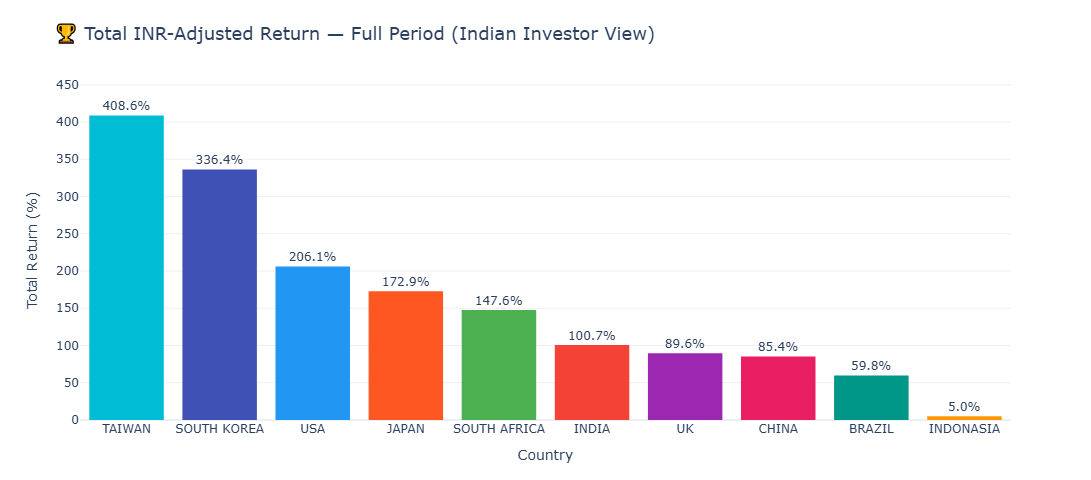

In [148]:
# ---- Bar chart: Total Return by Country ----
colors = [COUNTRY_COLORS[c] for c in summary_df['Country']]
fig = go.Figure(go.Bar(
    x=summary_df['Country'],
    y=summary_df['Total Return (%)'],
    marker_color=colors,
    text=[f"{v:.1f}%" for v in summary_df['Total Return (%)']],
    textposition='outside',
    marker_line_width=0
))
fig.update_layout(
    title=dict(text='🏆 Total INR-Adjusted Return — Full Period (Indian Investor View)', font=dict(size=18)),
    yaxis_title='Total Return (%)',
    xaxis_title='Country',
    height=480,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    showlegend=False,
    margin=dict(t=80, b=60)
)
fig.show()

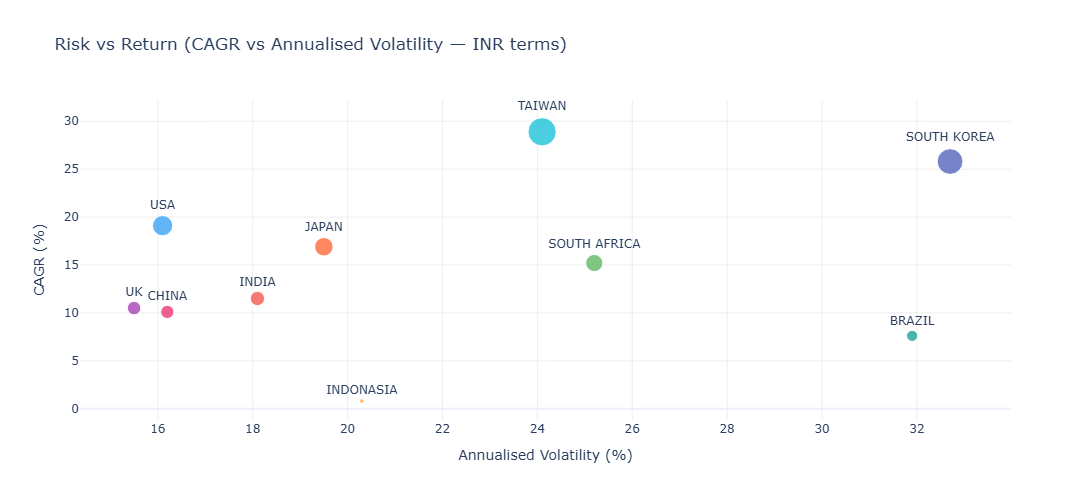

In [149]:
# ---- Risk vs Return Scatter ----
fig = px.scatter(
    summary_df,
    x='Ann. Volatility (%)',
    y='CAGR (%)',
    text='Country',
    size=[abs(v) + 5 for v in summary_df['Total Return (%)']],
    color='Country',
    color_discrete_map=COUNTRY_COLORS,
    title='Risk vs Return (CAGR vs Annualised Volatility — INR terms)',
    labels={'Ann. Volatility (%)': 'Annualised Volatility (%)', 'CAGR (%)': 'CAGR (%)'}
)
fig.update_traces(textposition='top center', marker=dict(line=dict(width=1, color='white')))
fig.update_layout(height=500, showlegend=False, title_font_size=17,
                  plot_bgcolor='rgba(0,0,0,0)', yaxis=dict(gridcolor='#eee'), xaxis=dict(gridcolor='#eee'))
fig.show()

## 7. 📈 Monthly Return % Comparison — All Countries

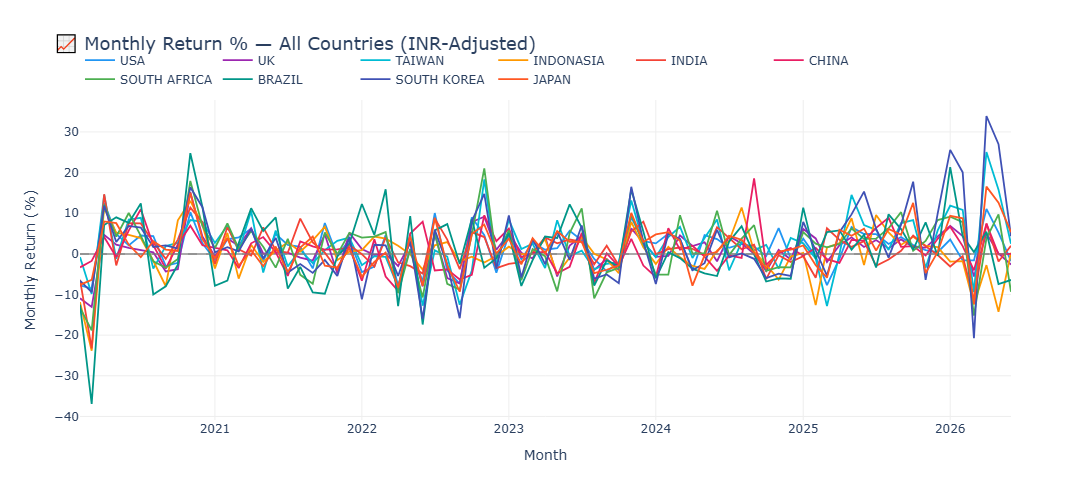

In [150]:
fig = go.Figure()
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Return_Pct'])
    fig.add_trace(go.Scatter(
        x=df['Month'],
        y=df['INR_Return_Pct'],
        name=country,
        line=dict(color=COUNTRY_COLORS[country], width=1.8),
        mode='lines'
    ))

fig.update_layout(
    title=dict(text='📈 Monthly Return % — All Countries (INR-Adjusted)', font=dict(size=18)),
    xaxis_title='Month',
    yaxis_title='Monthly Return (%)',
    height=500,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee', zeroline=True, zerolinecolor='#aaa'),
    xaxis=dict(gridcolor='#eee')
)
fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5)
fig.show()

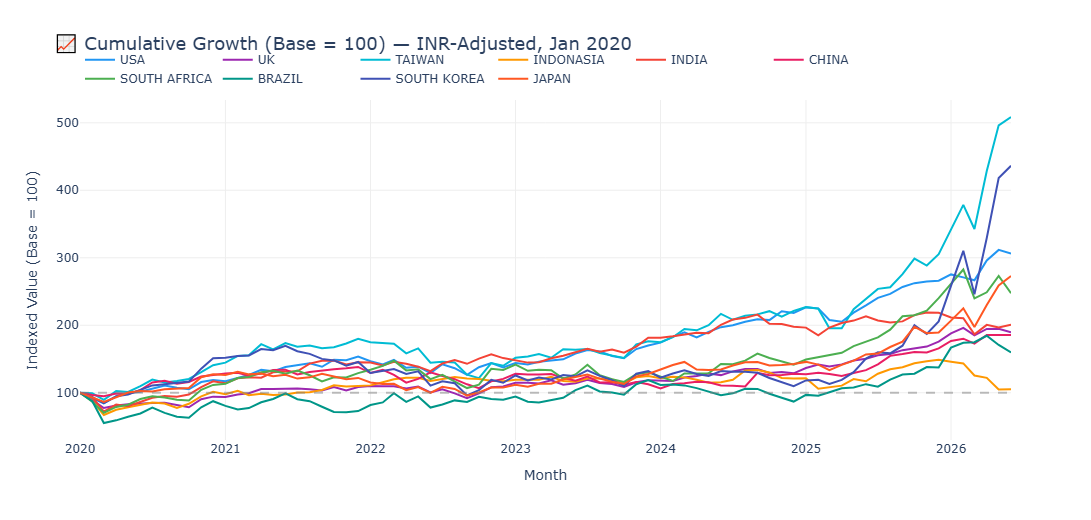

In [151]:
# ---- Normalised INR Index (base 100) — Cumulative Growth ----
fig = go.Figure()
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Index']).sort_values('Month')
    base = df['INR_Index'].iloc[0]
    normalized = df['INR_Index'] / base * 100
    fig.add_trace(go.Scatter(
        x=df['Month'],
        y=normalized,
        name=country,
        line=dict(color=COUNTRY_COLORS[country], width=2),
        mode='lines'
    ))

fig.add_hline(y=100, line_dash='dash', line_color='gray', opacity=0.5)
fig.update_layout(
    title=dict(text='📈 Cumulative Growth (Base = 100) — INR-Adjusted, Jan 2020', font=dict(size=18)),
    xaxis_title='Month',
    yaxis_title='Indexed Value (Base = 100)',
    height=520,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee')
)
fig.show()

## 8. 📊 P/E Ratio Comparison — All Countries

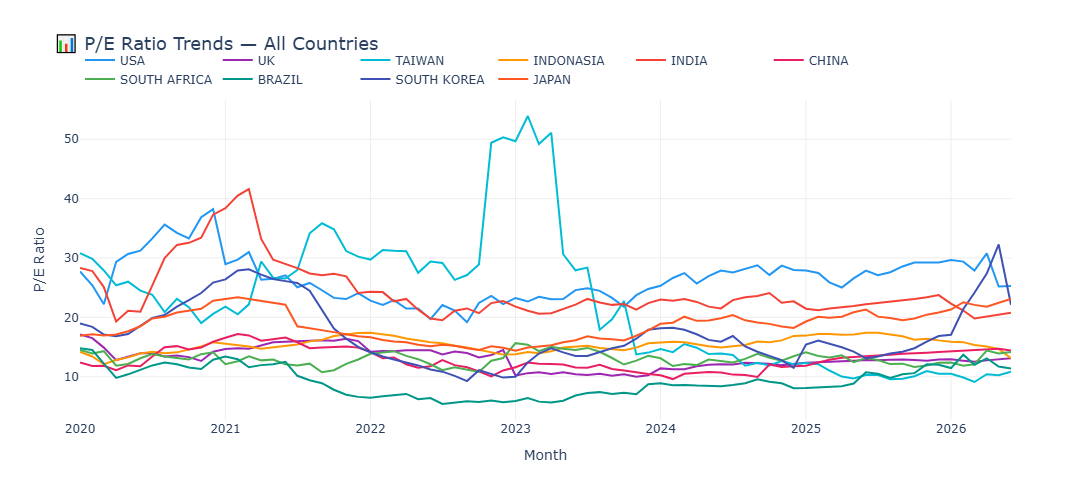

In [152]:
fig = go.Figure()
for country in COUNTRIES:
    df = combined[country].dropna(subset=['P/E'])
    fig.add_trace(go.Scatter(
        x=df['Month'],
        y=df['P/E'],
        name=country,
        line=dict(color=COUNTRY_COLORS[country], width=2),
        mode='lines'
    ))

fig.update_layout(
    title=dict(text='📊 P/E Ratio Trends — All Countries', font=dict(size=18)),
    xaxis_title='Month',
    yaxis_title='P/E Ratio',
    height=500,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee')
)
fig.show()

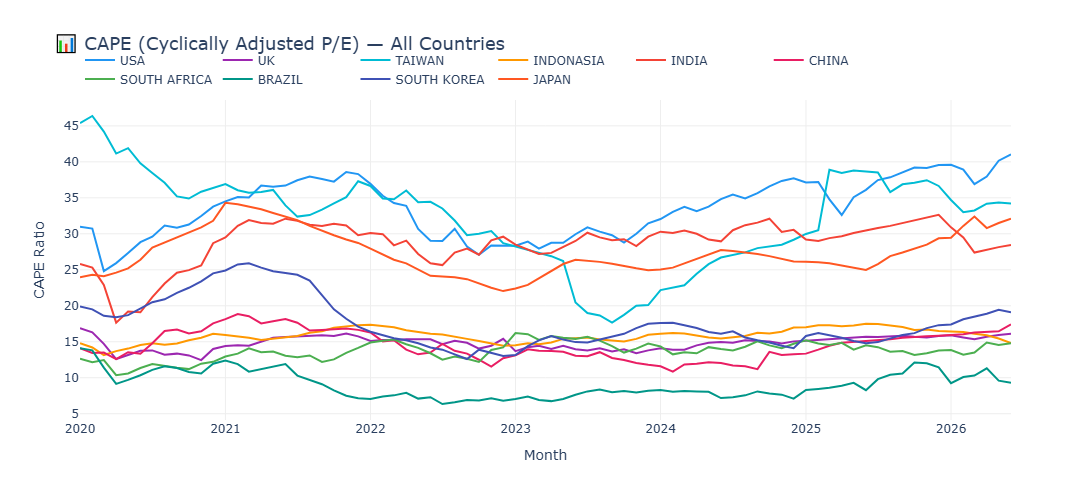

In [153]:
# ---- CAPE Comparison ----
fig = go.Figure()
for country in COUNTRIES:
    df = combined[country].dropna(subset=['CAPE'])
    fig.add_trace(go.Scatter(
        x=df['Month'],
        y=df['CAPE'],
        name=country,
        line=dict(color=COUNTRY_COLORS[country], width=2),
        mode='lines'
    ))

fig.update_layout(
    title=dict(text='📊 CAPE (Cyclically Adjusted P/E) — All Countries', font=dict(size=18)),
    xaxis_title='Month',
    yaxis_title='CAPE Ratio',
    height=500,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee')
)
fig.show()

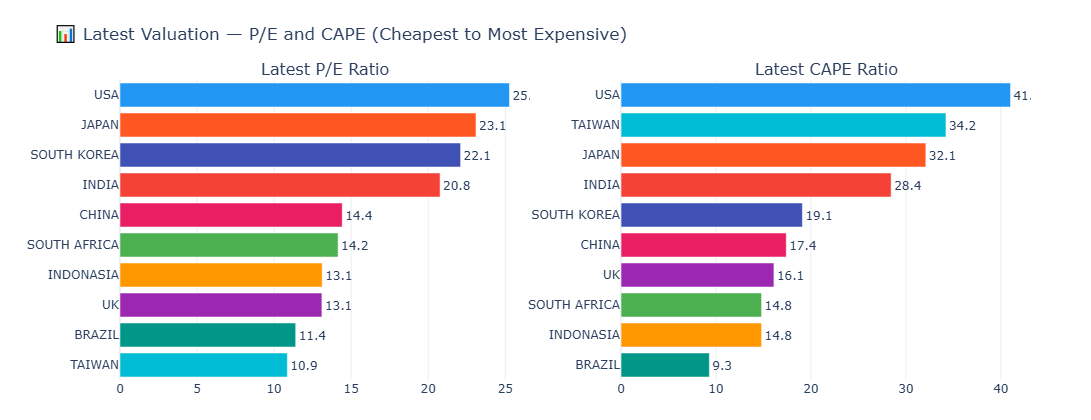

In [154]:
# ---- Latest P/E and CAPE bar chart (most recent month) ----
latest_pe   = {c: combined[c].dropna(subset=['P/E']).sort_values('Month')['P/E'].iloc[-1]   for c in COUNTRIES}
latest_cape = {c: combined[c].dropna(subset=['CAPE']).sort_values('Month')['CAPE'].iloc[-1] for c in COUNTRIES}

fig = make_subplots(rows=1, cols=2, subplot_titles=['Latest P/E Ratio', 'Latest CAPE Ratio'])

sorted_pe   = sorted(latest_pe.items(),   key=lambda x: x[1])
sorted_cape = sorted(latest_cape.items(), key=lambda x: x[1])

fig.add_trace(go.Bar(
    x=[v for _, v in sorted_pe],
    y=[c for c, _ in sorted_pe],
    orientation='h',
    marker_color=[COUNTRY_COLORS[c] for c, _ in sorted_pe],
    text=[f'{v:.1f}' for _, v in sorted_pe],
    textposition='outside',
    name='P/E'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=[v for _, v in sorted_cape],
    y=[c for c, _ in sorted_cape],
    orientation='h',
    marker_color=[COUNTRY_COLORS[c] for c, _ in sorted_cape],
    text=[f'{v:.1f}' for _, v in sorted_cape],
    textposition='outside',
    name='CAPE'
), row=1, col=2)

fig.update_layout(
    title=dict(text='📊 Latest Valuation — P/E and CAPE (Cheapest to Most Expensive)', font=dict(size=17)),
    height=420,
    showlegend=False,
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(l=120, r=60, t=80, b=40)
)
fig.update_xaxes(gridcolor='#eee')
fig.show()

## 9. 📉 Market Volatility Analysis

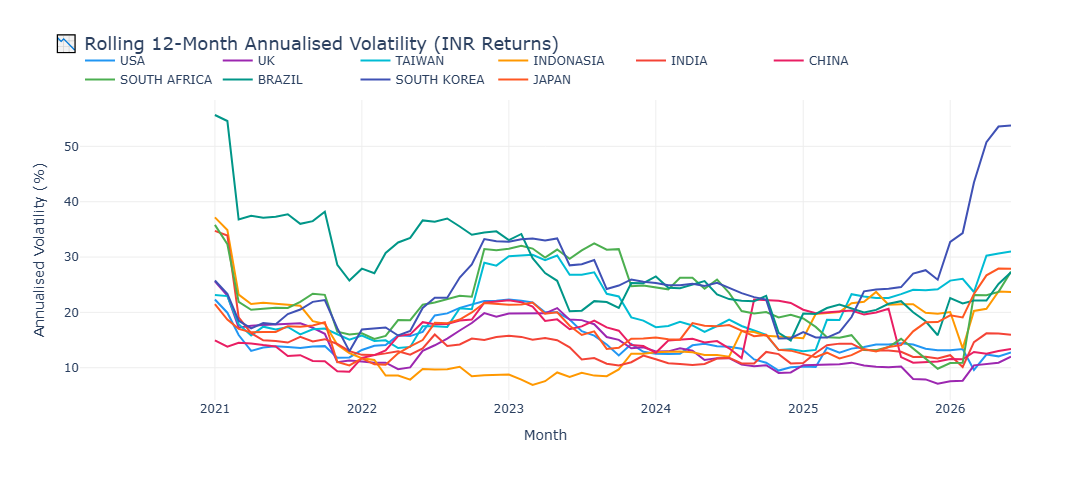

In [155]:
# Rolling 12-month annualised volatility for each country (INR returns)
fig = go.Figure()
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Return_Pct']).sort_values('Month')
    rolling_vol = df['INR_Return_Pct'].rolling(12).std() * np.sqrt(12)
    fig.add_trace(go.Scatter(
        x=df['Month'],
        y=rolling_vol,
        name=country,
        line=dict(color=COUNTRY_COLORS[country], width=2),
        mode='lines'
    ))

fig.update_layout(
    title=dict(text='📉 Rolling 12-Month Annualised Volatility (INR Returns)', font=dict(size=18)),
    xaxis_title='Month',
    yaxis_title='Annualised Volatility (%)',
    height=480,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee')
)
fig.show()

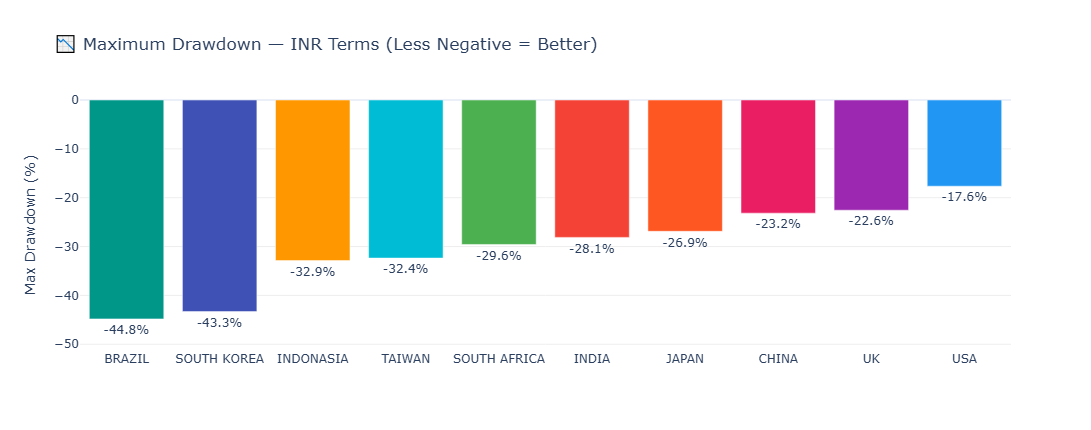

In [156]:
# ---- Max Drawdown Comparison ----
dd_rows = []
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Index']).sort_values('Month')
    rolling_max = df['INR_Index'].cummax()
    dd = (df['INR_Index'] - rolling_max) / rolling_max * 100
    dd_rows.append({'Country': country, 'Max_Drawdown': dd.min()})

dd_df = pd.DataFrame(dd_rows).sort_values('Max_Drawdown')

fig = go.Figure(go.Bar(
    x=dd_df['Country'],
    y=dd_df['Max_Drawdown'],
    marker_color=[COUNTRY_COLORS[c] for c in dd_df['Country']],
    text=[f'{v:.1f}%' for v in dd_df['Max_Drawdown']],
    textposition='outside'
))
fig.update_layout(
    title=dict(text='📉 Maximum Drawdown — INR Terms (Less Negative = Better)', font=dict(size=17)),
    yaxis_title='Max Drawdown (%)',
    height=430,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    showlegend=False
)
fig.show()

## 10. 🔗 Correlation Analysis: P/E, CAPE, Monthly Return

In [ ]:
# Pearson and Spearman correlation between P/E and next-month return, for each country
corr_rows = []
for country in COUNTRIES:
    df = combined[country].dropna(subset=['P/E','CAPE','INR_Return_Pct']).copy()
    df = df.sort_values('Month')
    df['Next_Month_Return'] = df['INR_Return_Pct'].shift(-1)
    df = df.dropna(subset=['Next_Month_Return'])

    for metric in ['P/E', 'CAPE']:
        pearson_r, pearson_p = stats.pearsonr(df[metric], df['Next_Month_Return'])
        spearman_r, spearman_p = spearmanr(df[metric], df['Next_Month_Return'])
        corr_rows.append({
            'Country':      country,
            'Metric':       metric,
            'Pearson_r':    round(pearson_r, 3),
            'Pearson_p':    round(pearson_p, 3),
            'Spearman_r':   round(spearman_r, 3),
            'Spearman_p':   round(spearman_p, 3)
        })

corr_df = pd.DataFrame(corr_rows)
print('📎 Correlation of P/E & CAPE with Next-Month Return:')
corr_df.style.format({'Pearson_r': '{:.3f}', 'Spearman_r': '{:.3f}'}) \
       .background_gradient(subset=['Pearson_r','Spearman_r'], cmap='RdYlGn', vmin=-0.5, vmax=0.5)

In [ ]:
# ---- Correlation Heatmap: P/E with next-month return ----
pe_corr_pivot = corr_df[corr_df['Metric']=='P/E'].set_index('Country')['Spearman_r']
cape_corr_pivot = corr_df[corr_df['Metric']=='CAPE'].set_index('Country')['Spearman_r']

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Spearman r: P/E vs Next-Month Return', 'Spearman r: CAPE vs Next-Month Return']
)

for col_idx, (series, label) in enumerate([(pe_corr_pivot, 'P/E'), (cape_corr_pivot, 'CAPE')], 1):
    sorted_s = series.sort_values()
    colors_bar = ['#d32f2f' if v < 0 else '#388e3c' for v in sorted_s.values]
    fig.add_trace(go.Bar(
        x=sorted_s.values,
        y=sorted_s.index,
        orientation='h',
        marker_color=colors_bar,
        text=[f'{v:.3f}' for v in sorted_s.values],
        textposition='outside',
        name=label
    ), row=1, col=col_idx)

fig.update_layout(
    title=dict(text='🔗 Correlation: P/E & CAPE with Next-Month Return (Spearman)', font=dict(size=17)),
    height=420,
    showlegend=False,
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(l=130, r=80, t=80, b=40)
)
fig.update_xaxes(gridcolor='#eee')
fig.add_vline(x=0, line_dash='dash', line_color='gray', row=1, col=1)
fig.add_vline(x=0, line_dash='dash', line_color='gray', row=1, col=2)
fig.show()

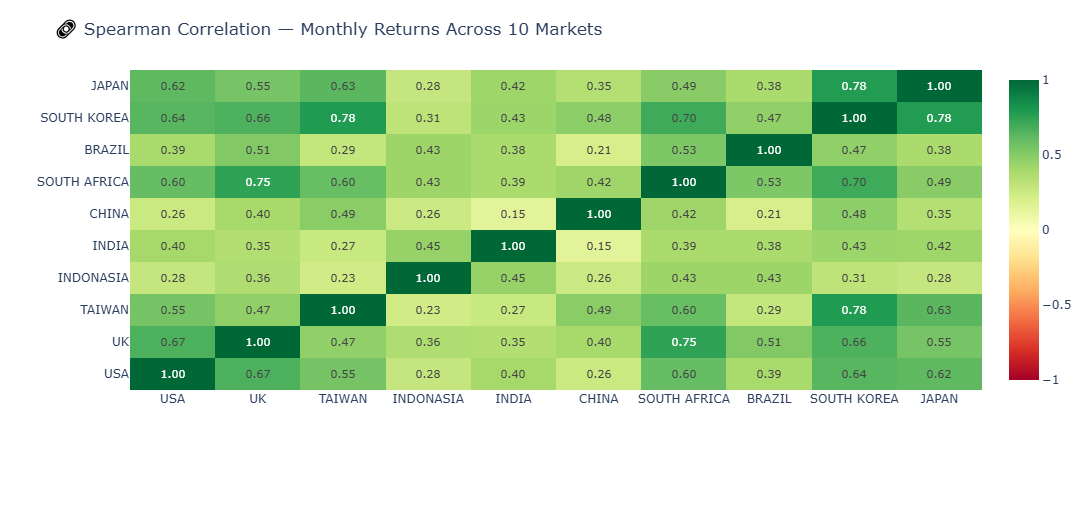

In [173]:
# ---- Cross-country correlation matrix (monthly INR returns) ----
ret_matrix = pd.DataFrame()
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Return_Pct']).set_index('Month')['INR_Return_Pct']
    ret_matrix[country] = df

corr_matrix = ret_matrix.corr(method='spearman')

fig = go.Figure(go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns.tolist(),
    y=corr_matrix.index.tolist(),
    colorscale='RdYlGn',
    zmin=-1, zmax=1, zmid=0,
    text=[[f'{v:.2f}' for v in row] for row in corr_matrix.values],
    texttemplate='%{text}',
    textfont={'size': 11},
    showscale=True
))
fig.update_layout(
    title=dict(text='🔗 Spearman Correlation — Monthly Returns Across 10 Markets', font=dict(size=17)),
    height=520,
    margin=dict(l=130, r=40, t=70, b=130)
)
fig.show()

## 11. 📆 Seasonal Analysis — Average Monthly Return by Calendar Month

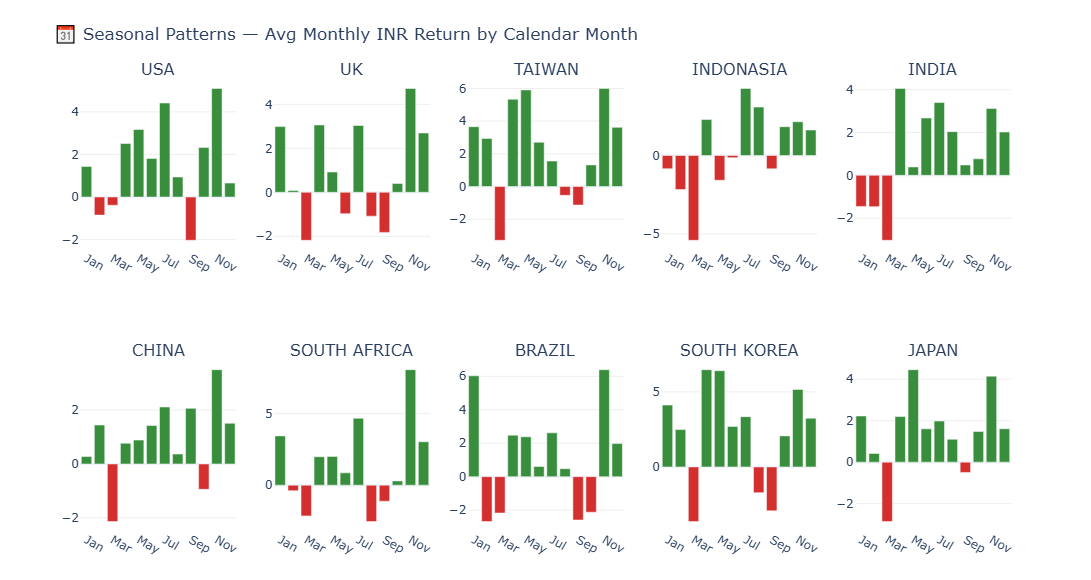

In [174]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig = make_subplots(
    rows=2, cols=5,
    subplot_titles=COUNTRIES,
    shared_yaxes=False
)

for idx, country in enumerate(COUNTRIES):
    row = idx // 5 + 1
    col = idx % 5 + 1
    df = combined[country].dropna(subset=['INR_Return_Pct']).copy()
    df['CalMonth'] = df['Month'].dt.month
    seasonal = df.groupby('CalMonth')['INR_Return_Pct'].mean()
    bar_colors = ['#d32f2f' if v < 0 else '#388e3c' for v in seasonal.values]

    fig.add_trace(go.Bar(
        x=[month_names[m-1] for m in seasonal.index],
        y=seasonal.values,
        marker_color=bar_colors,
        showlegend=False,
        name=country
    ), row=row, col=col)

fig.update_layout(
    title=dict(text='📆 Seasonal Patterns — Avg Monthly INR Return by Calendar Month', font=dict(size=17)),
    height=580,
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(t=80, b=50)
)
fig.update_yaxes(gridcolor='#eee')
fig.show()

## 12. 🔮 Forecasting: P/E and CAPE Trends (Holt-Winters)

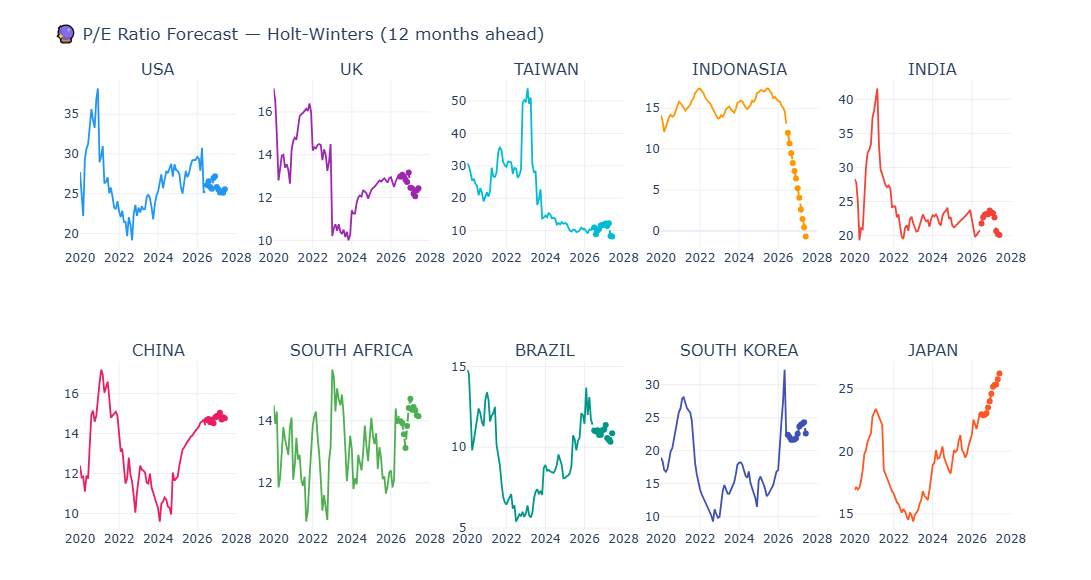

In [175]:
FORECAST_MONTHS = 12

fig = make_subplots(
    rows=2, cols=5,
    subplot_titles=COUNTRIES,
    shared_yaxes=False
)

for idx, country in enumerate(COUNTRIES):
    row = idx // 5 + 1
    col = idx % 5 + 1
    df = combined[country].dropna(subset=['P/E']).sort_values('Month')
    series = df.set_index('Month')['P/E']

    # Holt-Winters exponential smoothing
    try:
        model = ExponentialSmoothing(series, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
        forecast = model.forecast(FORECAST_MONTHS)
    except Exception:
        model = ExponentialSmoothing(series, trend='add').fit(optimized=True)
        forecast = model.forecast(FORECAST_MONTHS)

    color = COUNTRY_COLORS[country]

    # Historical
    fig.add_trace(go.Scatter(
        x=series.index, y=series.values,
        line=dict(color=color, width=1.8),
        showlegend=False, name=f'{country} Actual'
    ), row=row, col=col)

    # Forecast
    fig.add_trace(go.Scatter(
        x=forecast.index, y=forecast.values,
        line=dict(color=color, dash='dash', width=2),
        showlegend=False, name=f'{country} Forecast'
    ), row=row, col=col)

fig.update_layout(
    title=dict(text='🔮 P/E Ratio Forecast — Holt-Winters (12 months ahead)', font=dict(size=17)),
    height=580,
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(t=80, b=50)
)
fig.update_yaxes(gridcolor='#eee')
fig.show()

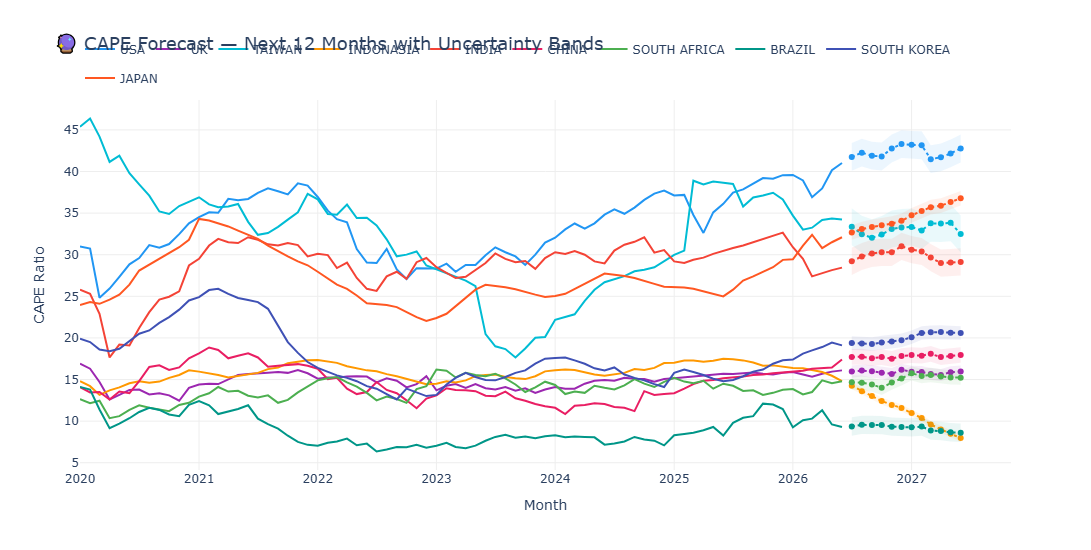

In [176]:
# ---- CAPE Forecasts with uncertainty bands ----
fig = go.Figure()

for country in COUNTRIES:
    df = combined[country].dropna(subset=['CAPE']).sort_values('Month')
    series = df.set_index('Month')['CAPE']

    try:
        model = ExponentialSmoothing(series, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
        forecast = model.forecast(FORECAST_MONTHS)
        resid_std = model.resid.std()
    except Exception:
        model = ExponentialSmoothing(series, trend='add').fit(optimized=True)
        forecast = model.forecast(FORECAST_MONTHS)
        resid_std = model.resid.std()

    color = COUNTRY_COLORS[country]

    # Historical line
    fig.add_trace(go.Scatter(
        x=series.index, y=series.values,
        line=dict(color=color, width=2),
        name=country, legendgroup=country, showlegend=True
    ))

    # Forecast dashed
    fig.add_trace(go.Scatter(
        x=forecast.index, y=forecast.values,
        line=dict(color=color, dash='dot', width=2),
        name=f'{country} Fcast', legendgroup=country, showlegend=False
    ))

    # Uncertainty band ±1.5 std
    upper = forecast + 1.5 * resid_std
    lower = forecast - 1.5 * resid_std
    fig.add_trace(go.Scatter(
        x=list(forecast.index) + list(forecast.index[::-1]),
        y=list(upper.values) + list(lower.values[::-1]),
        fill='toself',
        fillcolor=color,
        opacity=0.08,
        line=dict(color='rgba(0,0,0,0)'),
        showlegend=False, legendgroup=country
    ))

fig.update_layout(
    title=dict(text='🔮 CAPE Forecast — Next 12 Months with Uncertainty Bands', font=dict(size=18)),
    xaxis_title='Month',
    yaxis_title='CAPE Ratio',
    height=550,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee')
)
fig.show()

🔮 FORECAST 1: Based on Return Momentum


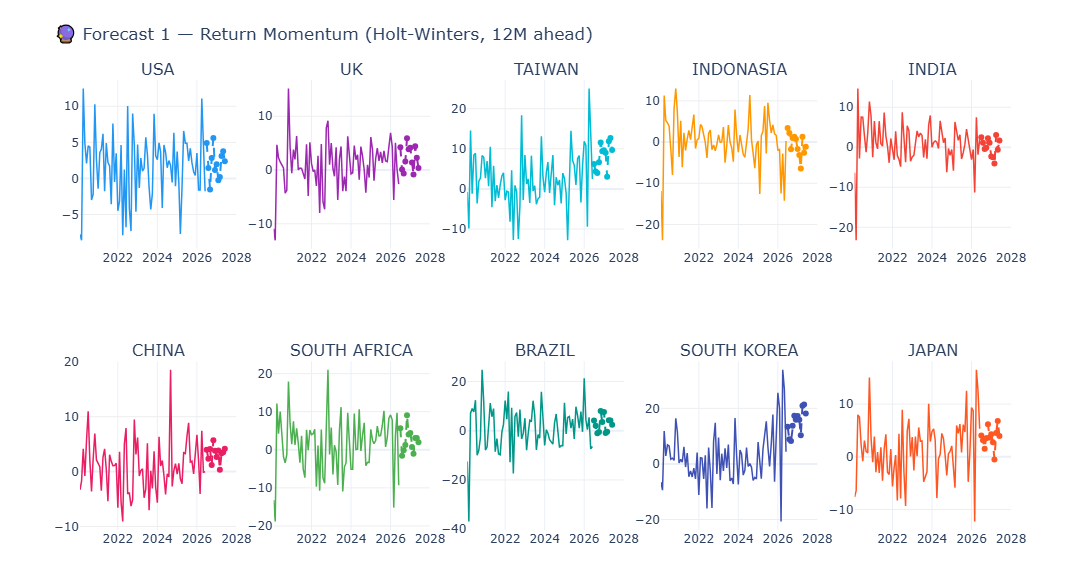


📋 Forecast 1 Summary:


,Country,Avg Forecasted Monthly Return (%),Direction
0,SOUTH KOREA,15.12%,↑ Positive
1,TAIWAN,8.18%,↑ Positive
2,JAPAN,3.66%,↑ Positive
3,CHINA,3.24%,↑ Positive
4,BRAZIL,2.78%,↑ Positive
5,SOUTH AFRICA,2.55%,↑ Positive
6,UK,2.24%,↑ Positive
7,USA,2.14%,↑ Positive
8,INDIA,0.14%,↑ Positive
9,INDONASIA,-0.56%,↓ Negative


In [177]:
# -------------------------------------------------------
# FORECAST 1 — Based on Return Momentum (INR_Return_Pct)
# -------------------------------------------------------
print('🔮 FORECAST 1: Based on Return Momentum')

fig = make_subplots(rows=2, cols=5, subplot_titles=COUNTRIES)
fcast1_summary = []

for idx, country in enumerate(COUNTRIES):
    row, col = idx // 5 + 1, idx % 5 + 1
    df = combined[country].dropna(subset=['INR_Return_Pct']).sort_values('Month')
    series = df.set_index('Month')['INR_Return_Pct']

    try:
        model    = ExponentialSmoothing(series, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
        forecast = model.forecast(FORECAST_MONTHS)
    except Exception:
        model    = ExponentialSmoothing(series, trend='add').fit(optimized=True)
        forecast = model.forecast(FORECAST_MONTHS)

    avg_fcast = forecast.mean()
    direction = '↑ Positive' if avg_fcast > 0 else '↓ Negative'
    fcast1_summary.append({'Country': country, 'Avg Forecasted Monthly Return (%)': round(avg_fcast, 2), 'Direction': direction})

    color = COUNTRY_COLORS[country]
    fig.add_trace(go.Scatter(x=series.index, y=series.values,
                             line=dict(color=color, width=1.5), showlegend=False), row=row, col=col)
    fig.add_trace(go.Scatter(x=forecast.index, y=forecast.values,
                             line=dict(color=color, dash='dash', width=2), showlegend=False), row=row, col=col)

fig.update_layout(title=dict(text='🔮 Forecast 1 — Return Momentum (Holt-Winters, 12M ahead)', font=dict(size=17)),
                  height=580, plot_bgcolor='rgba(0,0,0,0)', margin=dict(t=80, b=50))
fig.update_yaxes(gridcolor='#eee')
fig.show()

fcast1_df = pd.DataFrame(fcast1_summary).sort_values('Avg Forecasted Monthly Return (%)', ascending=False).reset_index(drop=True)
print('\n📋 Forecast 1 Summary:')
display(fcast1_df.style.format({'Avg Forecasted Monthly Return (%)': '{:.2f}%'})
        .background_gradient(subset=['Avg Forecasted Monthly Return (%)'], cmap='RdYlGn'))




🔮 FORECAST 2: Based on P/E Ratio


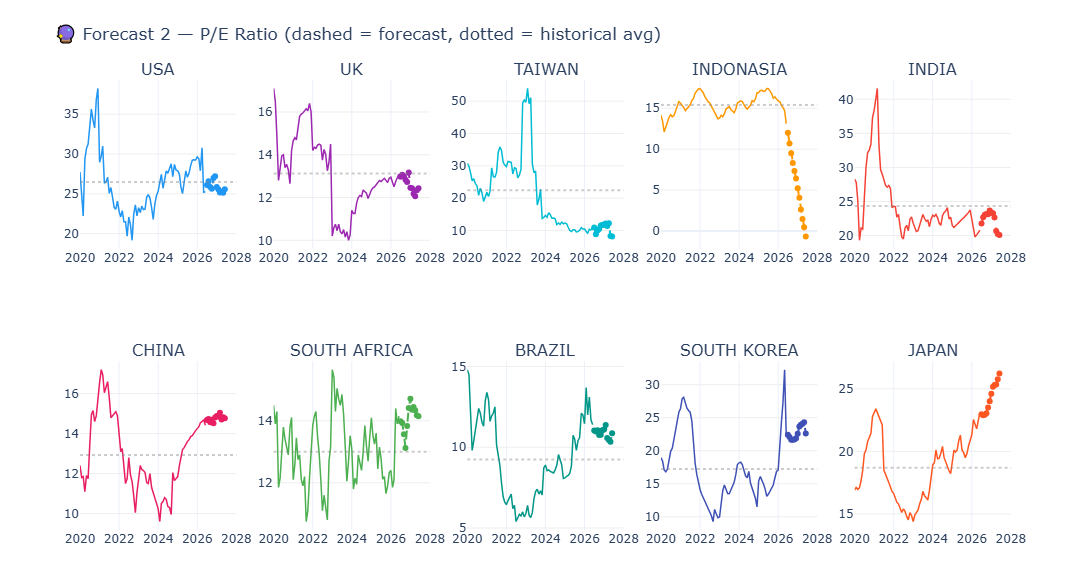


📋 Forecast 2 Summary:


,Country,Current P/E,5Y Avg P/E,Forecasted P/E,P/E Change,Signal
0,INDONASIA,13.1,15.4,-0.7,-13.81,🟢 Cheap
1,TAIWAN,10.9,22.5,8.2,-2.70,🟢 Cheap
2,BRAZIL,11.4,9.2,10.9,-0.53,🔴 Expensive
3,UK,13.1,13.1,12.4,-0.66,🟢 Cheap
4,SOUTH AFRICA,14.2,13.0,14.1,-0.00,🔴 Expensive
5,CHINA,14.4,12.9,14.8,+0.36,🔴 Expensive
6,INDIA,20.8,24.3,20.1,-0.70,🟢 Cheap
7,SOUTH KOREA,22.1,17.2,22.6,+0.52,🔴 Expensive
8,USA,25.3,26.5,25.6,+0.30,🟢 Cheap
9,JAPAN,23.1,18.7,26.2,+3.13,🔴 Expensive


In [178]:
# FORECAST 2 — Based on P/E Ratio
# -------------------------------------------------------
print('\n🔮 FORECAST 2: Based on P/E Ratio')

fig2 = make_subplots(rows=2, cols=5, subplot_titles=COUNTRIES)
fcast2_summary = []

for idx, country in enumerate(COUNTRIES):
    row, col = idx // 5 + 1, idx % 5 + 1
    df = combined[country].dropna(subset=['P/E']).sort_values('Month')
    series = df.set_index('Month')['P/E']
    current_pe = series.iloc[-1]
    avg_pe     = series.mean()

    try:
        model    = ExponentialSmoothing(series, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
        forecast = model.forecast(FORECAST_MONTHS)
    except Exception:
        model    = ExponentialSmoothing(series, trend='add').fit(optimized=True)
        forecast = model.forecast(FORECAST_MONTHS)

    fcast_pe  = forecast.iloc[-1]
    pe_change = fcast_pe - current_pe
    signal    = '🟢 Cheap' if fcast_pe < avg_pe else '🔴 Expensive'
    fcast2_summary.append({
        'Country':          country,
        'Current P/E':      round(current_pe, 1),
        '5Y Avg P/E':       round(avg_pe, 1),
        'Forecasted P/E':   round(fcast_pe, 1),
        'P/E Change':       round(pe_change, 2),
        'Signal':           signal
    })

    color = COUNTRY_COLORS[country]
    fig2.add_trace(go.Scatter(x=series.index, y=series.values,
                              line=dict(color=color, width=1.5), showlegend=False), row=row, col=col)
    fig2.add_trace(go.Scatter(x=forecast.index, y=forecast.values,
                              line=dict(color=color, dash='dash', width=2), showlegend=False), row=row, col=col)
    fig2.add_hline(y=avg_pe, line_dash='dot', line_color='gray', opacity=0.4, row=row, col=col)

fig2.update_layout(title=dict(text='🔮 Forecast 2 — P/E Ratio (dashed = forecast, dotted = historical avg)', font=dict(size=17)),
                   height=580, plot_bgcolor='rgba(0,0,0,0)', margin=dict(t=80, b=50))
fig2.update_yaxes(gridcolor='#eee')
fig2.show()

fcast2_df = pd.DataFrame(fcast2_summary).sort_values('Forecasted P/E').reset_index(drop=True)
print('\n📋 Forecast 2 Summary:')
display(fcast2_df.style.format({
    'Current P/E': '{:.1f}', '5Y Avg P/E': '{:.1f}',
    'Forecasted P/E': '{:.1f}', 'P/E Change': '{:+.2f}'
}).background_gradient(subset=['Forecasted P/E'], cmap='RdYlGn_r'))



🔮 FORECAST 3: Based on CAPE


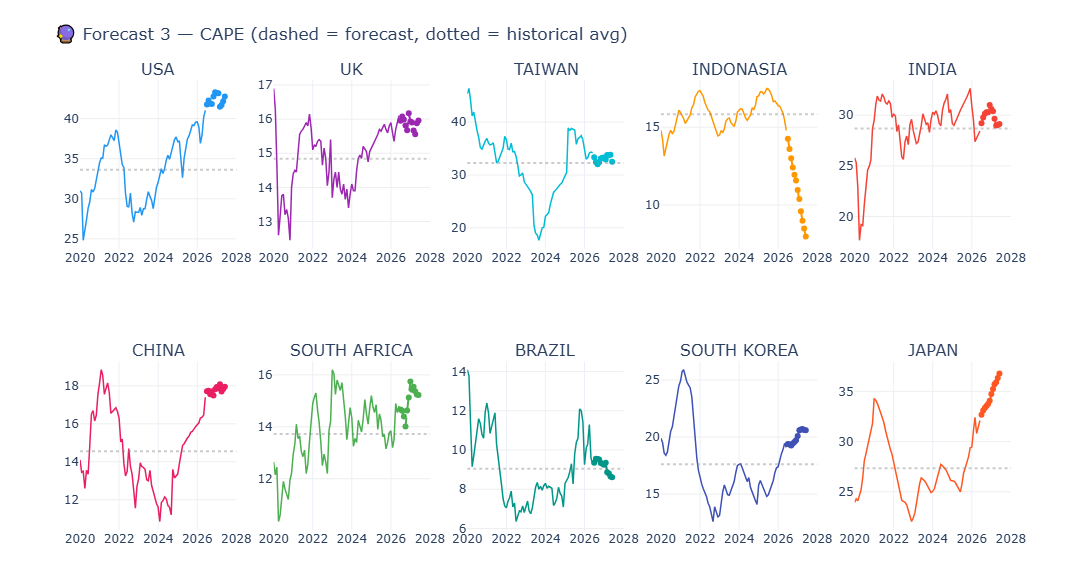


📋 Forecast 3 Summary:


,Country,Current CAPE,5Y Avg CAPE,Forecasted CAPE,CAPE Change,Signal
0,INDONASIA,14.8,15.8,8.0,-6.84,🟢 Cheap
1,BRAZIL,9.3,9.0,8.6,-0.69,🟢 Cheap
2,SOUTH AFRICA,14.8,13.7,15.2,+0.43,🔴 Expensive
3,UK,16.1,14.8,16.0,-0.14,🔴 Expensive
4,CHINA,17.4,14.5,17.9,+0.55,🔴 Expensive
5,SOUTH KOREA,19.1,17.6,20.6,+1.49,🔴 Expensive
6,INDIA,28.4,28.7,29.1,+0.69,🔴 Expensive
7,TAIWAN,34.2,32.3,32.5,-1.72,🔴 Expensive
8,JAPAN,32.1,27.3,36.8,+4.68,🔴 Expensive
9,USA,41.0,33.6,42.8,+1.74,🔴 Expensive


In [179]:
print('\n🔮 FORECAST 3: Based on CAPE')

fig3 = make_subplots(rows=2, cols=5, subplot_titles=COUNTRIES)
fcast3_summary = []

for idx, country in enumerate(COUNTRIES):
    row, col = idx // 5 + 1, idx % 5 + 1
    df = combined[country].dropna(subset=['CAPE']).sort_values('Month')
    series = df.set_index('Month')['CAPE']
    current_cape = series.iloc[-1]
    avg_cape     = series.mean()

    try:
        model    = ExponentialSmoothing(series, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
        forecast = model.forecast(FORECAST_MONTHS)
    except Exception:
        model    = ExponentialSmoothing(series, trend='add').fit(optimized=True)
        forecast = model.forecast(FORECAST_MONTHS)

    fcast_cape  = forecast.iloc[-1]
    cape_change = fcast_cape - current_cape
    signal      = '🟢 Cheap' if fcast_cape < avg_cape else '🔴 Expensive'
    fcast3_summary.append({
        'Country':            country,
        'Current CAPE':       round(current_cape, 1),
        '5Y Avg CAPE':        round(avg_cape, 1),
        'Forecasted CAPE':    round(fcast_cape, 1),
        'CAPE Change':        round(cape_change, 2),
        'Signal':             signal
    })

    color = COUNTRY_COLORS[country]
    fig3.add_trace(go.Scatter(x=series.index, y=series.values,
                              line=dict(color=color, width=1.5), showlegend=False), row=row, col=col)
    fig3.add_trace(go.Scatter(x=forecast.index, y=forecast.values,
                              line=dict(color=color, dash='dash', width=2), showlegend=False), row=row, col=col)
    fig3.add_hline(y=avg_cape, line_dash='dot', line_color='gray', opacity=0.4, row=row, col=col)

fig3.update_layout(title=dict(text='🔮 Forecast 3 — CAPE (dashed = forecast, dotted = historical avg)', font=dict(size=17)),
                   height=580, plot_bgcolor='rgba(0,0,0,0)', margin=dict(t=80, b=50))
fig3.update_yaxes(gridcolor='#eee')
fig3.show()

fcast3_df = pd.DataFrame(fcast3_summary).sort_values('Forecasted CAPE').reset_index(drop=True)
print('\n📋 Forecast 3 Summary:')
display(fcast3_df.style.format({
    'Current CAPE': '{:.1f}', '5Y Avg CAPE': '{:.1f}',
    'Forecasted CAPE': '{:.1f}', 'CAPE Change': '{:+.2f}'
}).background_gradient(subset=['Forecasted CAPE'], cmap='RdYlGn_r'))



🔮 FORECAST 4: Overall Combined Outlook

📋 Forecast 4 — Combined Outlook Ranking:


,Country,Avg Forecasted Monthly Return (%),Forecasted P/E,Forecasted CAPE,Overall_Score
1,SOUTH KOREA,15.12%,22.6,20.6,0.693
2,TAIWAN,8.18%,8.2,32.5,0.520
3,INDONASIA,-0.56%,-0.7,8.0,0.500
4,BRAZIL,2.78%,10.9,8.6,0.494
5,UK,2.24%,12.4,16.0,0.410
6,SOUTH AFRICA,2.55%,14.1,15.2,0.410
7,CHINA,3.24%,14.8,17.9,0.406
8,JAPAN,3.66%,26.2,36.8,0.178
9,INDIA,0.14%,20.1,29.1,0.177
10,USA,2.14%,25.6,42.8,0.092


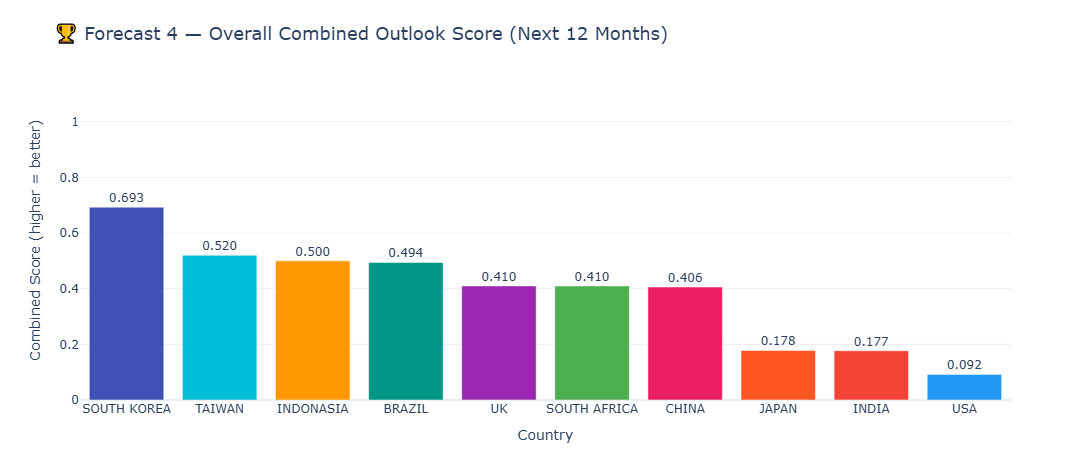

In [180]:
# FORECAST 4 — Overall Combined Score
# -------------------------------------------------------
print('\n🔮 FORECAST 4: Overall Combined Outlook')

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

combo = fcast1_df[['Country','Avg Forecasted Monthly Return (%)']].copy()
combo = combo.merge(fcast2_df[['Country','Forecasted P/E']], on='Country')
combo = combo.merge(fcast3_df[['Country','Forecasted CAPE']], on='Country')

# Score each: high return = good, low P/E = good, low CAPE = good
combo['Score_Return'] = scaler.fit_transform(combo[['Avg Forecasted Monthly Return (%)']])
combo['Score_PE']     = 1 - scaler.fit_transform(combo[['Forecasted P/E']])
combo['Score_CAPE']   = 1 - scaler.fit_transform(combo[['Forecasted CAPE']])

# Weighted composite
combo['Overall_Score'] = (
    combo['Score_Return'] * 0.50 +
    combo['Score_PE']     * 0.25 +
    combo['Score_CAPE']   * 0.25
).round(3)

combo_sorted = combo[['Country','Avg Forecasted Monthly Return (%)','Forecasted P/E','Forecasted CAPE','Overall_Score']] \
               .sort_values('Overall_Score', ascending=False).reset_index(drop=True)
combo_sorted.index += 1

print('\n📋 Forecast 4 — Combined Outlook Ranking:')
display(combo_sorted.style.format({
    'Avg Forecasted Monthly Return (%)': '{:.2f}%',
    'Forecasted P/E':                    '{:.1f}',
    'Forecasted CAPE':                   '{:.1f}',
    'Overall_Score':                     '{:.3f}'
}).background_gradient(subset=['Overall_Score'], cmap='RdYlGn'))

# Final ranking bar chart
fig4 = go.Figure(go.Bar(
    x=combo_sorted['Country'],
    y=combo_sorted['Overall_Score'],
    marker_color=[COUNTRY_COLORS[c] for c in combo_sorted['Country']],
    text=[f"{v:.3f}" for v in combo_sorted['Overall_Score']],
    textposition='outside'
))
fig4.update_layout(
    title=dict(text='🏆 Forecast 4 — Overall Combined Outlook Score (Next 12 Months)', font=dict(size=18)),
    yaxis_title='Combined Score (higher = better)',
    xaxis_title='Country',
    height=460,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee', range=[0, 1.15]),
    showlegend=False,
    margin=dict(t=80, b=60)
)
fig4.show()

## 13. 🏅 Best Market Scorecard — Last 5 Years

In [181]:
cutoff_5y = pd.Timestamp.now() - pd.DateOffset(years=5)

score_rows = []
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Index', 'P/E', 'CAPE']).copy()
    df5 = df[df['Month'] >= cutoff_5y].sort_values('Month')

    if len(df5) < 12:
        df5 = df.sort_values('Month').tail(60)

    start_val = df5['INR_Index'].iloc[0]
    end_val   = df5['INR_Index'].iloc[-1]
    n_years   = (df5['Month'].iloc[-1] - df5['Month'].iloc[0]).days / 365.25
    cagr_5y   = ((end_val / start_val) ** (1 / max(n_years, 0.1)) - 1) * 100
    vol_5y    = df5['INR_Return_Pct'].dropna().std() * np.sqrt(12)
    latest_pe   = df5['P/E'].iloc[-1]
    latest_cape = df5['CAPE'].iloc[-1]
    avg_pe_5y   = df5['P/E'].mean()
    pe_vs_avg   = (latest_pe / avg_pe_5y - 1) * 100  # positive = expensive vs history

    score_rows.append({
        'Country':         country,
        '5Y CAGR (%)':     round(cagr_5y, 1),
        '5Y Volatility':   round(vol_5y, 1),
        'Latest P/E':      round(latest_pe, 1),
        'Latest CAPE':     round(latest_cape, 1),
        'P/E vs 5Y Avg (%)': round(pe_vs_avg, 1)
    })

score_df = pd.DataFrame(score_rows)

# Simple composite score: high CAGR good, high vol bad, low P/E good, low P/E vs avg good
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

score_df['S_CAGR']     = scaler.fit_transform(score_df[['5Y CAGR (%)']])
score_df['S_Vol']      = 1 - scaler.fit_transform(score_df[['5Y Volatility']])
score_df['S_PE']       = 1 - scaler.fit_transform(score_df[['Latest P/E']])
score_df['S_CAPE']     = 1 - scaler.fit_transform(score_df[['Latest CAPE']])
score_df['S_PEvsAvg']  = 1 - scaler.fit_transform(score_df[['P/E vs 5Y Avg (%)']])

score_df['Composite_Score'] = (
    score_df['S_CAGR']    * 0.35 +
    score_df['S_Vol']     * 0.20 +
    score_df['S_PE']      * 0.20 +
    score_df['S_CAPE']    * 0.15 +
    score_df['S_PEvsAvg'] * 0.10
).round(3)

display_cols = ['Country', '5Y CAGR (%)', '5Y Volatility', 'Latest P/E', 'Latest CAPE', 'P/E vs 5Y Avg (%)', 'Composite_Score']
score_display = score_df[display_cols].sort_values('Composite_Score', ascending=False).reset_index(drop=True)
print('🏅 Best Markets Scorecard — Last 5 Years:')
score_display.style.format({'5Y CAGR (%)': '{:.1f}%', '5Y Volatility': '{:.1f}%', 'Composite_Score': '{:.3f}'}) \
             .background_gradient(subset=['Composite_Score'], cmap='RdYlGn')

🏅 Best Markets Scorecard — Last 5 Years:


,Country,5Y CAGR (%),5Y Volatility,Latest P/E,Latest CAPE,P/E vs 5Y Avg (%),Composite_Score
0,TAIWAN,25.2%,24.8%,10.900000,34.200000,-50.400000,0.777
1,UK,12.5%,13.3%,13.100000,16.100000,3.000000,0.695
2,SOUTH AFRICA,13.5%,23.7%,14.200000,14.800000,9.200000,0.599
3,BRAZIL,12.3%,26.0%,11.400000,9.300000,36.500000,0.596
4,CHINA,8.0%,16.9%,14.400000,17.400000,15.500000,0.559
5,INDONASIA,1.0%,16.1%,13.100000,14.800000,-16.600000,0.531
6,INDIA,8.9%,13.6%,20.800000,28.400000,-7.900000,0.487
7,JAPAN,18.0%,19.9%,23.100000,32.100000,27.200000,0.473
8,USA,17.0%,15.2%,25.300000,41.000000,-0.100000,0.459
9,SOUTH KOREA,22.4%,35.2%,22.100000,19.100000,41.100000,0.458


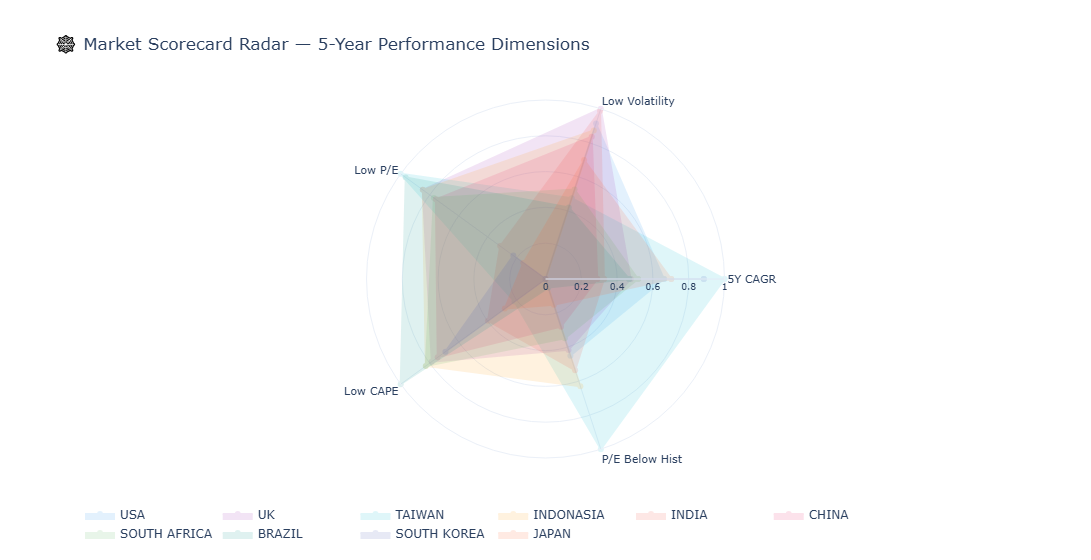

In [182]:
# ---- Radar chart: Composite scores per dimension ----
dims = ['S_CAGR', 'S_Vol', 'S_PE', 'S_CAPE', 'S_PEvsAvg']
dim_labels = ['5Y CAGR', 'Low Volatility', 'Low P/E', 'Low CAPE', 'P/E Below Hist']

fig = go.Figure()
for _, row in score_df.iterrows():
    vals = [row[d] for d in dims]
    vals_closed = vals + [vals[0]]
    labels_closed = dim_labels + [dim_labels[0]]
    fig.add_trace(go.Scatterpolar(
        r=vals_closed,
        theta=labels_closed,
        fill='toself',
        name=row['Country'],
        line=dict(color=COUNTRY_COLORS[row['Country']], width=2),
        fillcolor=COUNTRY_COLORS[row['Country']],
        opacity=0.12
    ))

fig.update_layout(
    title=dict(text='🕸️ Market Scorecard Radar — 5-Year Performance Dimensions', font=dict(size=17)),
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1], tickfont=dict(size=9)),
        angularaxis=dict(tickfont=dict(size=11))
    ),
    showlegend=True,
    legend=dict(orientation='h', yanchor='bottom', y=-0.25),
    height=560
)
fig.show()

## 14. 🔭 2026 Trend Analysis: Which Market Looks Best for Next 6/12 Months?

In [183]:
# Use last 6 months of data to evaluate momentum and valuation
cutoff_6m = pd.Timestamp.now() - pd.DateOffset(months=6)

outlook_rows = []
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Index', 'P/E', 'CAPE']).sort_values('Month')
    df6m = df[df['Month'] >= cutoff_6m]

    if len(df6m) < 2:
        df6m = df.tail(6)

    # 6-month momentum
    momentum_6m = (df6m['INR_Index'].iloc[-1] / df6m['INR_Index'].iloc[0] - 1) * 100

    # PE trend (slope via linregress)
    pe_series = df6m['P/E'].dropna().values
    if len(pe_series) >= 3:
        pe_slope, *_ = np.polyfit(range(len(pe_series)), pe_series, 1)
    else:
        pe_slope = 0

    # CAPE trend
    cape_series = df6m['CAPE'].dropna().values
    if len(cape_series) >= 3:
        cape_slope, *_ = np.polyfit(range(len(cape_series)), cape_series, 1)
    else:
        cape_slope = 0

    latest_pe   = df['P/E'].iloc[-1]
    latest_cape = df['CAPE'].iloc[-1]

    outlook_rows.append({
        'Country':         country,
        '6M Momentum (%)': round(momentum_6m, 1),
        'P/E Trend':       round(pe_slope, 2),     # negative = P/E falling = valuation improving
        'CAPE Trend':      round(cape_slope, 2),
        'Latest P/E':      round(latest_pe, 1),
        'Latest CAPE':     round(latest_cape, 1)
    })

outlook_df = pd.DataFrame(outlook_rows)

# Scoring: high momentum, low valuation, falling P/E = good
outlook_df['Score_Mom']  = scaler.fit_transform(outlook_df[['6M Momentum (%)']])
outlook_df['Score_PE']   = 1 - scaler.fit_transform(outlook_df[['Latest P/E']])
outlook_df['Score_CAPE'] = 1 - scaler.fit_transform(outlook_df[['Latest CAPE']])
outlook_df['Score_PETrend'] = 1 - scaler.fit_transform(outlook_df[['P/E Trend']])  # falling P/E = good

outlook_df['Outlook_Score'] = (
    outlook_df['Score_Mom']     * 0.35 +
    outlook_df['Score_PE']      * 0.25 +
    outlook_df['Score_CAPE']    * 0.25 +
    outlook_df['Score_PETrend'] * 0.15
).round(3)

out_display = outlook_df[['Country','6M Momentum (%)','Latest P/E','Latest CAPE','P/E Trend','CAPE Trend','Outlook_Score']] \
              .sort_values('Outlook_Score', ascending=False).reset_index(drop=True)

print('🔭 6-Month Outlook Scorecard — 2026:')
out_display.style.format({'6M Momentum (%)': '{:.1f}%', 'Outlook_Score': '{:.3f}'}) \
           .background_gradient(subset=['Outlook_Score'], cmap='RdYlGn')

🔭 6-Month Outlook Scorecard — 2026:


,Country,6M Momentum (%),Latest P/E,Latest CAPE,P/E Trend,CAPE Trend,Outlook_Score
0,BRAZIL,-4.2%,11.400000,9.300000,-0.150000,-0.010000,0.685
1,TAIWAN,49.0%,10.900000,34.200000,0.120000,0.070000,0.674
2,UK,0.9%,13.100000,16.100000,0.050000,0.070000,0.609
3,CHINA,4.9%,14.400000,17.400000,0.060000,0.240000,0.590
4,SOUTH KOREA,68.9%,22.100000,19.100000,1.740000,0.370000,0.578
5,SOUTH AFRICA,-5.5%,14.200000,14.800000,0.490000,0.290000,0.552
6,INDONASIA,-28.1%,13.100000,14.800000,-0.500000,-0.310000,0.546
7,JAPAN,31.9%,23.100000,32.100000,0.240000,0.370000,0.410
8,INDIA,-5.2%,20.800000,28.400000,-0.270000,-0.450000,0.374
9,USA,11.2%,25.300000,41.000000,-0.900000,0.340000,0.292


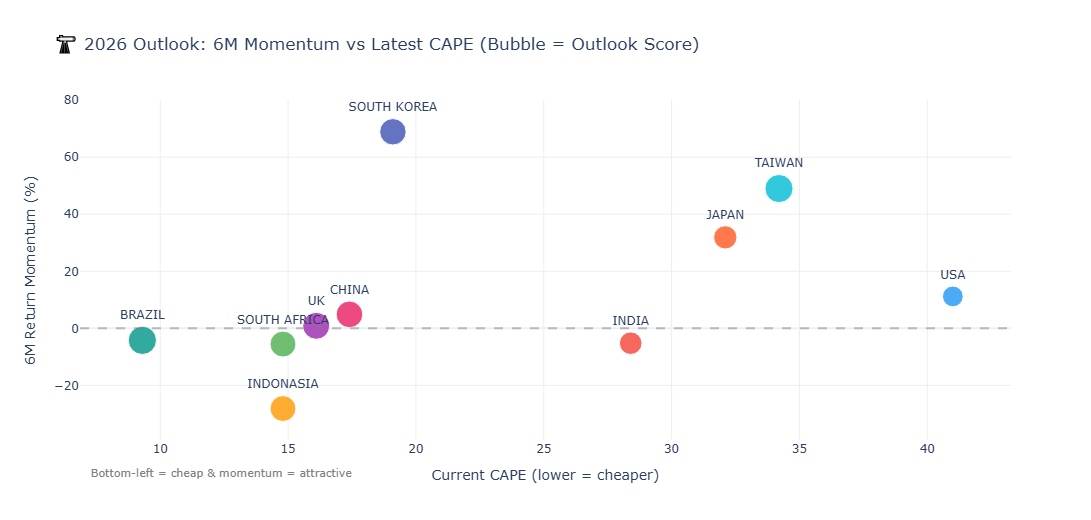

In [184]:
# ---- Bubble Chart: Momentum vs CAPE, bubble = Outlook Score ----
fig = px.scatter(
    out_display,
    x='Latest CAPE',
    y='6M Momentum (%)',
    size=[s * 60 + 10 for s in out_display['Outlook_Score']],
    color='Country',
    color_discrete_map=COUNTRY_COLORS,
    text='Country',
    title='🔭 2026 Outlook: 6M Momentum vs Latest CAPE (Bubble = Outlook Score)',
    labels={'Latest CAPE': 'Current CAPE (lower = cheaper)', '6M Momentum (%)': '6M Return Momentum (%)'}
)
fig.update_traces(textposition='top center', marker=dict(opacity=0.8, line=dict(width=1, color='white')))
fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5)
fig.update_layout(
    height=520,
    showlegend=False,
    title_font_size=17,
    plot_bgcolor='rgba(0,0,0,0)',
    xaxis=dict(gridcolor='#eee'),
    yaxis=dict(gridcolor='#eee'),
    annotations=[dict(
        text='Bottom-left = cheap & momentum = attractive',
        xref='paper', yref='paper', x=0.01, y=-0.12,
        showarrow=False, font=dict(size=11, color='gray')
    )]
)
fig.show()

## 15. 📊 Year-on-Year Bar Chart — Grouped by Country

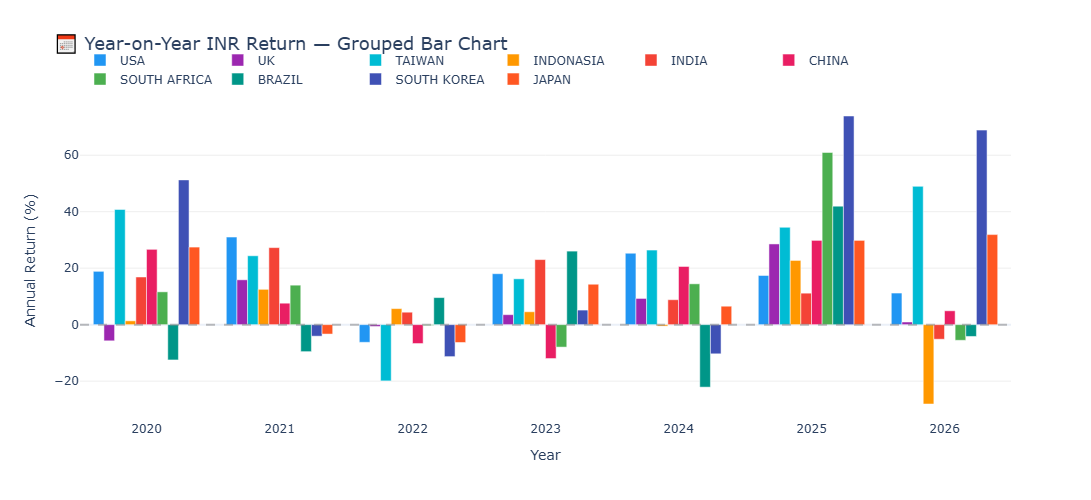

In [185]:
fig = go.Figure()

years = sorted(yearly_df['Year'].unique())
for country in COUNTRIES:
    ydata = yearly_df[yearly_df['Country'] == country].set_index('Year')['Annual_Return_Pct']
    fig.add_trace(go.Bar(
        name=country,
        x=[str(y) for y in years],
        y=[ydata.get(y, None) for y in years],
        marker_color=COUNTRY_COLORS[country]
    ))

fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5)
fig.update_layout(
    title=dict(text='📅 Year-on-Year INR Return — Grouped Bar Chart', font=dict(size=18)),
    barmode='group',
    xaxis_title='Year',
    yaxis_title='Annual Return (%)',
    height=500,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

## 16. 📝 Final Summary & Conclusions

In [186]:
print('=' * 70)
print('📋  SUMMARY REPORT — GLOBAL MARKET ANALYSIS (Indian Investor View)')
print('=' * 70)

print('\n🏆  TOP 3 MARKETS BY TOTAL INR-ADJUSTED RETURN:')
top3 = summary_df.head(3)
for i, row in top3.iterrows():
    print(f"  {i+1}. {row['Country']:15s} → Total: {row['Total Return (%)']:+.1f}%  |  CAGR: {row['CAGR (%)']:.1f}%  |  Volatility: {row['Ann. Volatility (%)']:.1f}%")

print('\n💰  BEST RISK-ADJUSTED RETURN (Return/Risk Ratio):')
best_sharpe = summary_df.sort_values('Return/Risk', ascending=False).head(3)
for i, (_, row) in enumerate(best_sharpe.iterrows()):
    print(f"  {i+1}. {row['Country']:15s} → Return/Risk: {row['Return/Risk']:.2f}")

print('\n🔭  TOP 3 MARKETS FOR NEXT 6-12 MONTHS (2026 Outlook Score):')
top3_out = out_display.head(3)
for i, (_, row) in enumerate(top3_out.iterrows()):
    print(f"  {i+1}. {row['Country']:15s} → Score: {row['Outlook_Score']:.3f}  |  6M Momentum: {row['6M Momentum (%)']:+.1f}%  |  CAPE: {row['Latest CAPE']:.1f}")

print('\n📊  CHEAPEST MARKET BY CURRENT CAPE:')
cheapest = sorted(latest_cape.items(), key=lambda x: x[1])[:3]
for i, (c, v) in enumerate(cheapest):
    print(f'  {i+1}. {c:15s} → CAPE: {v:.1f}')

print('\n⚠️   NOTE: This is a data-driven quantitative analysis.')
print('     Always combine with qualitative research before investing.')
print('=' * 70)

📋  SUMMARY REPORT — GLOBAL MARKET ANALYSIS (Indian Investor View)

🏆  TOP 3 MARKETS BY TOTAL INR-ADJUSTED RETURN:
  1. TAIWAN          → Total: +408.6%  |  CAGR: 28.9%  |  Volatility: 24.1%
  2. SOUTH KOREA     → Total: +336.4%  |  CAGR: 25.8%  |  Volatility: 32.7%
  3. USA             → Total: +206.1%  |  CAGR: 19.1%  |  Volatility: 16.1%

💰  BEST RISK-ADJUSTED RETURN (Return/Risk Ratio):
  1. TAIWAN          → Return/Risk: 1.20
  2. USA             → Return/Risk: 1.18
  3. JAPAN           → Return/Risk: 0.87

🔭  TOP 3 MARKETS FOR NEXT 6-12 MONTHS (2026 Outlook Score):
  1. BRAZIL          → Score: 0.685  |  6M Momentum: -4.2%  |  CAPE: 9.3
  2. TAIWAN          → Score: 0.674  |  6M Momentum: +49.0%  |  CAPE: 34.2
  3. UK              → Score: 0.609  |  6M Momentum: +0.9%  |  CAPE: 16.1

📊  CHEAPEST MARKET BY CURRENT CAPE:


AttributeError: 'numpy.float64' object has no attribute 'items'